In [27]:
# data sets
from tdc.utils import get_reaction_type

# rdkit things
from rdkit import Chem
from rdkit.Chem import GetPeriodicTable
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw
from rdkit.Chem.Draw import ReactionToImage
from rdkit.Chem.Draw import MolToImage
from rdkit.Chem import AllChem
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

# standard libraries
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import copy 
from tqdm import tqdm

# machine learning libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

# used to explore hyperparameter space
from sklearn.model_selection import RandomizedSearchCV # took way too long
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

from sklearn.base import BaseEstimator
from scipy.stats import uniform, loguniform, randint
from sklearn.decomposition import PCA


### (1) Retrieve the cleaned data from data_exploration.ipynb to use in our model. 
Structure it to use in model.

In [28]:
alchemy_elements = {'C', 'Cl', 'F', 'H', 'N', 'O', 'S'}

molecule_types_df = pd.read_pickle(
   "/Users/joshuahoang/Documents/Chem-C242-Final-Project-Organic-Reactions/Collected Data/Alchemy-v20191129/final_version_with_smiles_coords_angles.pkl"
)

reaction_types_df = pd.read_csv(
    "/Users/joshuahoang/Documents/Chem-C242-Final-Project-Organic-Reactions/Collected Data/uspto_50k_processed.csv"
)

display(molecule_types_df)
display(reaction_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles,coords,node_angles
0,2859833,9,0.226164,0.000067,0.300531,-352.128828,-0.236722,-352.076085,99.201621,-352.088194,-352.075141,0.063809,0.180558,1919.249225,CC#CC[C@H](C)CCC,"[[1.4191, 1.0679, -0.7249], [0.642, 0.2423, -1...","{0: [], 1: [1.995018720626831], 2: [2.02745819..."
1,3148292,9,0.180782,0.000058,0.293098,-386.820766,-0.241536,-386.774917,84.670738,-386.784878,-386.773973,0.051562,1.302656,1420.242859,C#CC[C@@H]1CO[C@@H]1CC,"[[0.8276, 0.4718, 0.3516], [0.3443, -0.9649, 0...","{0: [], 1: [1.9479340314865112], 2: [1.9565199..."
2,3607838,9,0.205922,0.000057,0.307544,-388.062328,-0.224965,-388.018758,86.198178,-388.028208,-388.017814,0.082579,1.284923,1257.238492,CC[C@H]1[C@H]2CCO[C@]21C,"[[1.1241, 1.687, -0.1877], [0.1225, 0.564, -0....","{0: [], 1: [1.9696639776229858], 2: [2.1605758..."
3,9540153,11,0.160845,0.000056,0.195923,-515.046508,-0.203538,-515.001198,95.801267,-515.010568,-515.000254,-0.007615,4.074910,1600.220066,COc1nccc2c1OCC2,"[[-5.1197, 7.1633, 5.3178], [-4.7619, 6.1363, ...","{0: [], 1: [2.1072568893432617], 2: [1.9805861..."
4,340363,10,0.177712,0.000057,0.254495,-403.843164,-0.248943,-403.800346,95.147725,-403.809426,-403.799402,0.005552,4.111533,1442.171110,CC1=CC[C@H]2C[C@@H]2[C@H]1C#N,"[[0.4915, 0.3661, 0.231], [0.5473, 0.8513, -1....","{0: [], 1: [2.125312328338623, 2.0248210430145..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202574,9581016,10,0.120222,0.000051,0.179768,-450.915828,-0.244325,-450.872449,88.581216,-450.881390,-450.871505,-0.064557,6.434535,1541.115465,CNc1cc(C#N)ncn1,"[[1.1884, 0.0204, -0.0006], [0.1768, 0.0285, -...","{0: [], 1: [2.1844115257263184], 2: [2.1464011..."
202575,9706527,10,0.130179,0.000053,0.189401,-438.632624,-0.231340,-438.589755,96.102362,-438.598674,-438.588811,-0.041938,0.338522,1628.839361,C#Cc1ccnc(OC)c1,"[[1.2218, 0.0872, -0.2336], [0.234, 1.1131, -0...","{0: [], 1: [2.0464351177215576], 2: [2.0328996..."
202576,9760179,10,0.119919,0.000051,0.163827,-450.920199,-0.232783,-450.875248,89.074794,-450.884399,-450.874304,-0.068956,4.337358,1497.024559,CNc1nccc(C#N)n1,"[[1.2711, 0.1905, 0.01], [0.3996, -0.033, 1.14...","{0: [], 1: [2.162799835205078], 2: [2.02789354..."
202577,9845175,10,0.119740,0.000050,0.191354,-454.722866,-0.251374,-454.680504,89.026059,-454.689065,-454.679560,-0.060020,5.263580,1611.219983,COc1cncc(C#N)c1,"[[0.733, 0.0993, -0.1025], [1.2403, 0.3389, -1...","{0: [], 1: [2.067808151245117], 2: [2.18707561..."


,reactant,product,category
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9
...,...,...,...
35111,COC(=O)c1ccc(C(=O)OCc2ccccc2)cc1F,COC(=O)c1ccc(C(=O)O)cc1F,6
35112,C=CCOC(=O)N1CCc2nnc(NN)cc2C1.CC(C)=O,C=CCOC(=O)N1CCc2nnc(NN=C(C)C)cc2C1,1
35113,FC1(F)CCNC1.O=C(O)c1ccncc1NC(=O)c1nc(C2CC2)ccc...,O=C(Nc1cnccc1C(=O)N1CCC(F)(F)C1)c1nc(C2CC2)ccc...,2
35114,CC(=O)Cl.CC(C)(C)OC(=O)NCCO,CC(=O)OCCNC(=O)OC(C)(C)C,2


Pipeline

(a) The GNN will take each molecule as a pooling of the atoms as nodes and the bonds as edges and lets each atom update its features by aggreating from its neighbors. 

(b) After this messaging, pool atoms to molecule to predict the target features that will be used in the decision tree for the reaction type. 

     - 12 columns are physics-relevent feature columns
     - 9/12 of the physics-relevent ones do not have too bad overlap

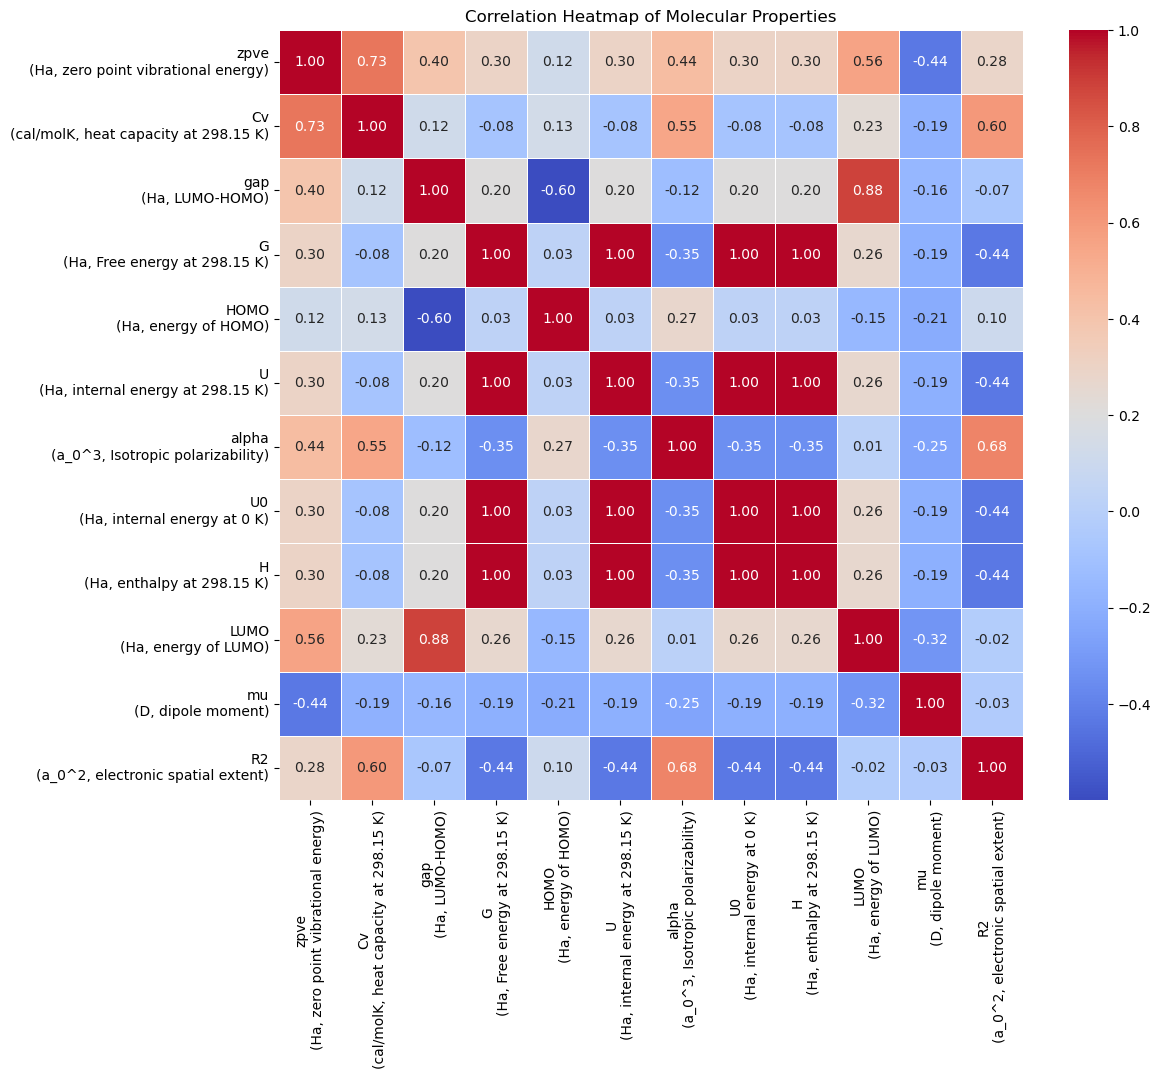

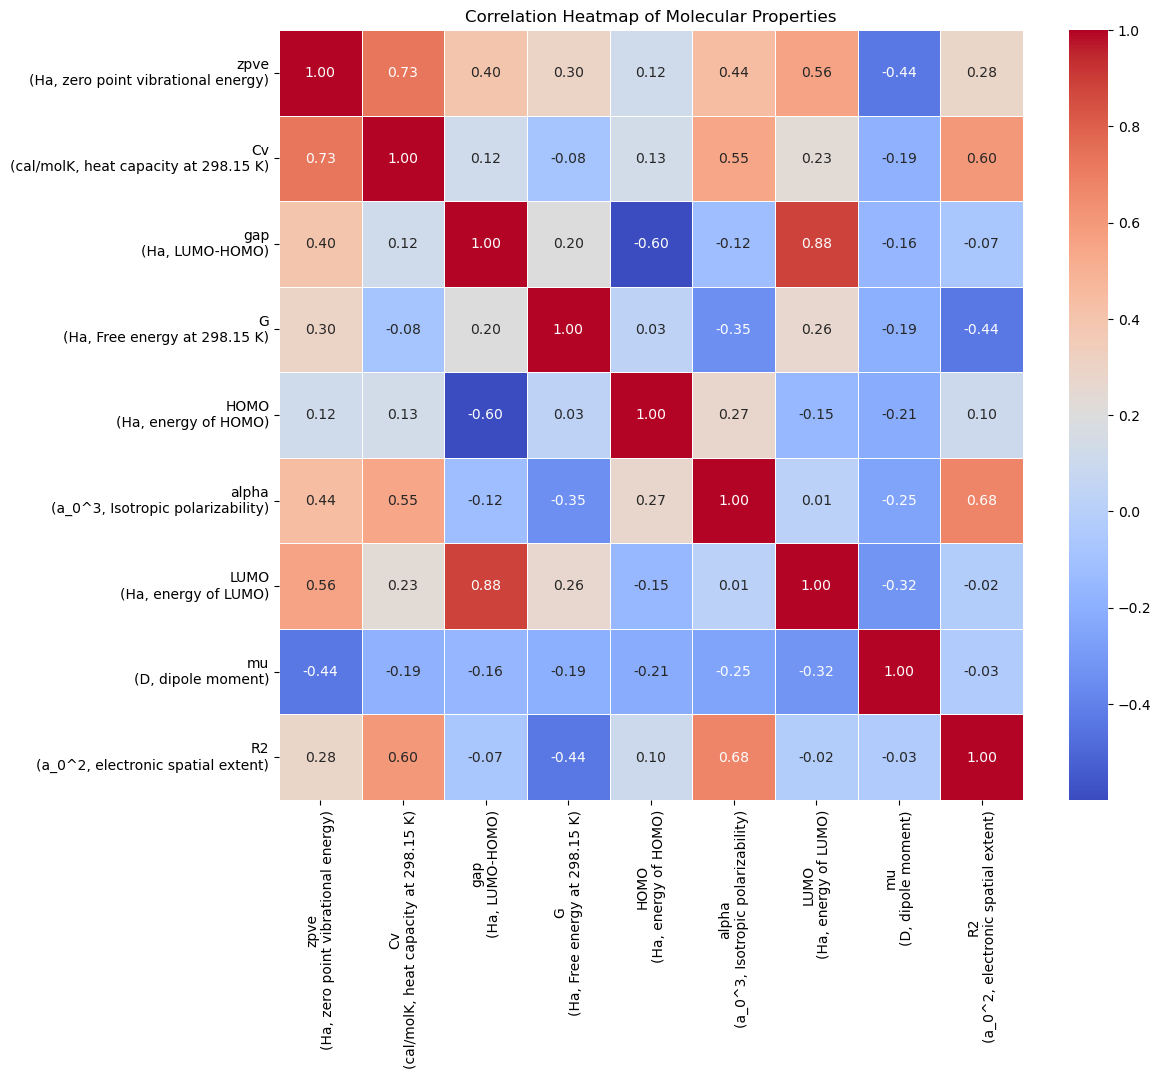

In [29]:
def plot_heatmap(df):
    plt.figure(figsize=(12,10))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Molecular Properties")
    plt.show()

# 12 that are physics-relevent target features
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'coords', 
    'node_angles'
    ])
plot_heatmap(molecule_targets_df)

# G, U, U0, H: G = U + PV - TS = H - TS, so we only need 1 -> keep G
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'coords',
    'node_angles',
    'U\n(Ha, internal energy at 298.15 K)',
    'U0\n(Ha, internal energy at 0 K)', 
    'H\n(Ha, enthalpy at 298.15 K)', 
])
plot_heatmap(molecule_targets_df)

### (2) Focus on making the GNN with the alchemy DFT data. 

Turn all the data into a graph structure. We choose the features that only the organic chemists care for which is geometrty, resonance, if it is in a ring, etc. Aromaticity is already in bond order. 

In [30]:
"""
NOTE:
Using one-hot encoding instead of raw integer values for categorical features (like atomic number, degree,
hybridization, etc.) prevents model from assuming a false numeric ordering (e.g., O > N > C).
Previously, and stupidly, values like 6, 7, 8 implicitly suggested linear relationships that are not chemically meaningful.
Each category is treated as distinct and orthogonal.
"""

# discrete categories for features
alchemy_elements = list(alchemy_elements)
degree_set = [0, 1, 2, 3, 4, 5]
numH_set = [0, 1, 2, 3, 4]
charge_set = [-1, 0, 1]
hybridization_set = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]

def one_hot(value, choices):
    return [int(value == c) for c in choices]

def compute_angle(a, b, c, pos):
    ba = pos[a] - pos[b]
    bc = pos[c] - pos[b]

    cos_theta = torch.dot(ba, bc) / (torch.norm(ba) * torch.norm(bc) + 1e-8)
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)

    angle = torch.acos(cos_theta).item()  # radians
    return angle

def padded_angle_vector(atom_idx, mol, pos, max_angles=6):
    """
    Compute all pairwise bond angles around one atom, then pad/truncate to fixed length.
    Also returns a mask so the model knows which angle entries are real and which are padding. (It will learn.)
    """
    atom = mol.GetAtomWithIdx(atom_idx)
    nbr_indices = [nbr.GetIdx() for nbr in atom.GetNeighbors()]
    # ONLY HEAVY ATOMS AND NOT HYDROGENS

    angles = []
    for i in range(len(nbr_indices)):
        for j in range(i + 1, len(nbr_indices)):
            a = nbr_indices[i]
            c = nbr_indices[j]
            angle = compute_angle(a, atom_idx, c, pos)
            angles.append(angle)

    angles = sorted(angles)

    real_count = min(len(angles), max_angles)
    angles = angles[:max_angles]
    mask = [1.0] * real_count

    if len(angles) < max_angles:
        pad = max_angles - len(angles)
        angles = angles + [0.0] * pad
        mask = mask + [0.0] * pad

    return angles + mask

# one-hot by turning into basis vectors
def atom_feature_vector(atom, mol, pos, max_angles=6):
    return (
        one_hot(atom.GetSymbol(), alchemy_elements) +  # atomic number, e.g. 6=C, 7=N, 8=O, 17=Cl
        one_hot(atom.GetDegree(), degree_set) +        # number of directly bonded neighbors
        one_hot(atom.GetTotalNumHs(), numH_set) +      # total attached hydrogens (implicit + explicit)
        one_hot(atom.GetFormalCharge(), charge_set) +  # formal charge on the atom
        [int(atom.GetIsAromatic())] +                  # aromatic atom flag: 1 if aromatic else 0
        [int(atom.IsInRing())] +                       # ring membership flag: 1 if atom is in a ring else 0
        one_hot(atom.GetHybridization(), hybridization_set) +  # hybridization enum value (sp, sp2, sp3, etc.)
        padded_angle_vector(atom.GetIdx(), mol, pos, max_angles=max_angles)  # padded local angle vector + mask
    )

bond_types = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]
stereo_types = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
]

def bond_feature_vector(bond, pos):

    i = bond.GetBeginAtomIdx()
    j = bond.GetEndAtomIdx()
    distance = torch.norm(pos[i] - pos[j]).item()  # now uses coordinates pulled from the Alchemy sdf file

    return (
        one_hot(bond.GetBondType(), bond_types) +   # bond order: categorical instead of numeric
        [int(bond.IsInRing())] +                    # ring membership flag for bond
        one_hot(bond.GetStereo(), stereo_types) +   # stereochemistry enum for bond geometry
        [distance]                                  # bond distance
    )

# this function is specifically to turn alchemy molecules to graphs 
# refer @smiles_to_graph_uspto below
def smiles_to_graph_alchemy(smi, coords, y, max_angles=6):
    """
    Convert a SMILES string + Alchemy coordinates to a PyTorch Geometric Data object.
    Nodes represent atoms, and edges represent bonds.
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None

    # coordinates are now taken directly from the Alchemy sdf file, not approximated from RDKit embedding
    pos = torch.tensor(coords, dtype=torch.float)

    # sanity check: coordinates must align with atom order in the SMILES-derived RDKit molecule
    if pos.shape[0] != mol.GetNumAtoms():
        return None

    # atom features
    atom_features = [atom_feature_vector(atom, mol, pos, max_angles=max_angles) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    # edge features
    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_feature_vector(bond, pos)

        edge_index.append((i, j))
        edge_attr.append(bf)

        edge_index.append((j, i))
        edge_attr.append(bf)
        # undirected graph, both directions

    # convert to tensor
    edge_feature_dim = len(
        one_hot(Chem.rdchem.BondType.SINGLE, bond_types) +
        [0] +
        one_hot(Chem.rdchem.BondStereo.STEREONONE, stereo_types) +
        [0.0]
    )

    if len(edge_index) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, edge_feature_dim), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # targets
    y = torch.tensor(y, dtype=torch.float).view(1, -1)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        pos=pos,   # 3D coordinates from the Alchemy sdf file
        y=y
    )

Convert all the data into graphs to work in the GNN. Then, normalize the molecule features.

In [31]:
# make the graph dataset
graph_dataset = []
for idx, row in molecule_types_df.iterrows():
    graph = smiles_to_graph_alchemy(
        row['smiles'], 
        row['coords'], # added to get higher R^2
        row[molecule_targets_df.columns].astype(float).values
    )
    if graph is not None:
        graph_dataset.append(graph)

# g = graph_dataset[0]
# print(g.x.shape)            # [num_atoms, num_node_features]
# print(g.edge_index.shape)   # [2, num_edges]
# print(g.y.shape)            # should be 9
# okay great nothing exploded

# normalize features that the gnn predicts
# these are all continuous values so normalize them all
all_y = torch.stack([g.y for g in graph_dataset])
y_mean = all_y.mean(dim = 0)
y_std = all_y.std(dim = 0).clamp_min(1e-8) # avoid div by 0 error

for g in graph_dataset: 
    g.y = (g.y - y_mean) / y_std

# no need to normalize most original node features as they are all one hot and categorical
# HOWEVER, the padded node angle vector is continuous, while the mask is binary
# so normalize only the padded angle part, not the mask
# convention from atom_feature_vector:
# ... + padded angles (length = max_angles) + mask (length = max_angles)
max_angles = 6 # square with an x for 6 pairs

all_x = torch.cat([g.x for g in graph_dataset], dim=0)

angle_mean = all_x[:, -2*max_angles:-max_angles].mean(dim=0)
angle_std = all_x[:, -2*max_angles:-max_angles].std(dim=0).clamp_min(1e-8)

for g in graph_dataset:
    g.x[:, -2*max_angles:-max_angles] = (
        g.x[:, -2*max_angles:-max_angles] - angle_mean
    ) / angle_std

# normalize edge feature that is continuous i.e. the distance of the bond only 
# check @bond_feature_vector

# these are all categorical and shove into one hot
# except distance check @bond_feature_vector
all_edge_attr = torch.cat([g.edge_attr for g in graph_dataset], dim=0)

dist_mean = all_edge_attr[:, -1].mean()
dist_std = all_edge_attr[:, -1].std().clamp_min(1e-8)

for g in graph_dataset:
    g.edge_attr[:, -1] = (g.edge_attr[:, -1] - dist_mean) / dist_std

# NOTE: PCA could be another option to do, but I want the chemical variation so skip 
# and come back later if PCA is really needed
# all_y = torch.stack([g.y.squeeze(0) for g in graph_dataset]).numpy()
# 
# # fit PCA
# pca = PCA(n_components=5)
# y_reduced = pca.fit_transform(all_y)
# 
# # replace targets with reduced representation
# for g, y_new in zip(graph_dataset, y_reduced):
#     g.y = torch.tensor(y_new, dtype=torch.float).view(1, -1)
# 
# # check variance retained
# print(pca.explained_variance_ratio_)
# print("Total variance retained:", pca.explained_variance_ratio_.sum())

Now use an architechture that does not ignore bond or edges like GCNConv. 
 - GINEConv: Propagates node features but not edge features.
 - I have tried others that propograte the bond features but they exponentially increase run time even on savio. 

In [32]:
class GNN(torch.nn.Module): 
    # screw around with the hidden_dim to get better regression statistic
    # number of y predictions is out_dim in case of future change
    def __init__(self, in_channels, edge_dim, hidden_dim, out_dim = molecule_targets_df.shape[1], dropout=0.2): 
        super().__init__()

        # node features into hidden space
        self.node_encoder = nn.Linear(in_channels, hidden_dim)

        # edge features into hidden space
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        # GINEConv 
        self.conv1 = GINEConv(
            nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        self.conv2 = GINEConv(
            nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        self.conv3 = GINEConv(
            nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )
        
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # encode raw node and edge features into hidden space
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)
    
        # first graph convolution block
        x_res = x # skip connection
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # second graph convolution block
        x_res = x # skip connection
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # third graph convolution block
        x_res = x # skip connection
        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)
        x = x + x_res # skip connection
    
        # pool from atom space to molecule space
        x = global_mean_pool(x, batch)
    
        # readout MLP
        x_res = x # skip connection
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
        x = self.lin2(x)
        return x 
        
class Trainer: 
    def __init__(
        self,
        model,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        loss_type="smoothl1",   # "mse" or "smoothl1"
        beta=0.5, # for smooth l1; 1-2 is more MSE like, 0.5 is more L1 like
        device="cpu"
    ):
        super().__init__()

        self.model = model.to(device)
        self.device = device
        self.optimizer = optimizer(self.model.parameters(), lr=lr)

        if loss_type == "mse": self.loss_function = torch.nn.MSELoss()
        elif loss_type == "smoothl1": self.loss_function = torch.nn.SmoothL1Loss(beta=beta)
        else: raise ValueError(f"Unsupported loss_type: {loss_type}'")

    def train_one_epoch(self, loader): 
        self.model.train() # training 'mode'
        total_loss = 0.0

        for batch in loader: 
            batch = batch.to(self.device)
            self.optimizer.zero_grad() # past grad not needed as we evaluate

            # mps needs contiguous tensors for smooth l1, so reshape and make contiguous
            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            target = batch.y
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()

            loss = self.loss_function(pred, target)
            loss.backward() # find the gradients
            self.optimizer.step() # update the weights
            total_loss += loss.item() # tack on loss
        
        return total_loss / len(loader) # average loss per batch 
    
    # used for testing phase
    @torch.no_grad()
    def evaluate(self, loader): 
        self.model.eval()
        total_loss = 0.0
        all_preds = []  # Collect all predictions
        all_targets = []  # Collect all targets

        for batch in loader: 
            batch = batch.to(self.device) 
            # prediction and actual (i.e. target)
            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch) 
            target = batch.y
            # mps needs contiguous tensors for smoothl1, so reshape and make contiguous
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()
            loss = self.loss_function(pred, target)
            total_loss += loss.item()
            all_preds.append(pred.cpu())  # Store predictions for R² calculation
            all_targets.append(target.cpu())  # Store targets for R² calculation
            # move to cpu else gpu memory kaboom like grandma
        
        all_preds = torch.cat(all_preds, dim=0)  # Concatenate all predictions
        all_targets = torch.cat(all_targets, dim=0)  # Concatenate all targets
        
        # Compute average R² across outputs (measure of accuracy for regression)
        ss_res = ((all_preds - all_targets) ** 2).sum(dim=0)  # Sum of squared residuals per output
        ss_tot = ((all_targets - all_targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)      

        r2_per_output = 1 - (ss_res / ss_tot)  # R² per output
        avg_r2 = r2_per_output.mean().item()  # Average R² across all outputs
        
        return total_loss / len(loader), avg_r2
    
    
    def fit(self, train_loader, val_loader, epochs, show_progress = True): 
        train_losses = []
        val_losses = []
        train_r2s = []
        val_r2s = []  # Track R² history

        best_val = float("inf")
        best_train = None
        best_val_r2 = -float("inf")  # Track best R²
        best_train_r2 = None

        for epoch in range(1, epochs + 1): 
            train_loss = self.train_one_epoch(train_loader)
            _, train_r2 = self.evaluate(train_loader)     # R² on 66%
            val_loss, val_r2 = self.evaluate(val_loader)  # R² on 33% on like 3 fold val for ex

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_r2s.append(train_r2)
            val_r2s.append(val_r2)

            if val_loss < best_val: 
                best_val = val_loss
                best_train = train_loss
                best_val_r2 = val_r2
                best_train_r2 = train_r2

            if show_progress: 
                print(
                    f"Epoch {epoch}: "
                    f"train={train_loss:.4f}, "
                    f"train_r2={train_r2:.4f}, "
                    f"val={val_loss:.4f}, "
                    f"val_r2={val_r2:.4f}"
                )

        return {
            # arrays for plotting history
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_r2s": train_r2s,
            "val_r2s": val_r2s,

            # best values from validation
            "best_train_loss": best_train,
            "best_val_loss": best_val,
            "best_train_r2": best_train_r2,
            "best_val_r2": best_val_r2 
        }

Functions to facilitate running the model.

In [33]:
def run_single_split(
        model_class,
        train_graphs,
        val_graphs,
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        show_progress=False
):
    """
    Train one model on one train/validation split.
    Returns metrics and the trained model.
    """
    # arguments for model class (fixed)
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)

    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    results = trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        show_progress=show_progress
    )

    return {
        "model": trainer.model,

        "best_train_loss": results["best_train_loss"],
        "best_val_loss": results["best_val_loss"],
        "best_train_r2": results["best_train_r2"],
        "best_val_r2": results["best_val_r2"],

        "train_losses": results["train_losses"],
        "val_losses": results["val_losses"],
        "train_r2s": results["train_r2s"],
        "val_r2s": results["val_r2s"],
    }


# replace accuracy with the R^2 regression statistic
# function used to see if the model scales well and does not explode
def KFoldCrossValidation(
    model_class,
    graph_dataset,
    k=3,
    batch_size=32,
    epochs=20,
    hidden_dim=64,
    dropout=0.2,
    lr=1e-3,
    optimizer=torch.optim.Adam,
    loss_type="smoothl1",
    beta=0.5,
    device="cpu",
    early_break=False,
    show_progress=False,
    make_plots=True,
    verbose=True, # print per fold results
    random_state=67
): 
    """
    Run either:
    - k=1: a single train/validation split
    - k>1: k-fold cross validation

    Returns only metrics for evaluation / hyperparameter search.
    Does NOT return a model. (No need.)
    """
    if k == 1: # k = 1 was used during code creation to check fast
        indices = list(range(len(graph_dataset)))
        train_idx, val_idx = train_test_split(
            indices, 
            test_size=0.2, 
            random_state=random_state, 
            shuffle=True
        )
        splits = [(train_idx, val_idx)]
    else:
        kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
        splits = kf.split(graph_dataset)

    # contain results for each fold to compute average and std dev
    train_loss_list = []
    val_loss_list = []
    train_r2_list = []
    val_r2_list = []  

    all_train_losses = [] 
    all_val_losses = []  
    all_train_r2s = []
    all_val_r2s = []  

    for fold, (train_idx, val_idx) in enumerate(splits): 

        # split data 
        train_graphs = [graph_dataset[i] for i in train_idx]
        val_graphs = [graph_dataset[i] for i in val_idx]

        # train and evaluate model on this fold
        fold_results = run_single_split(
            model_class=model_class,
            train_graphs=train_graphs,
            val_graphs=val_graphs, # run_single_split expects raw graphs, not loaders
            batch_size=batch_size,
            epochs=epochs,
            hidden_dim=hidden_dim,
            dropout=dropout,
            lr=lr,
            optimizer=optimizer,
            loss_type=loss_type,
            beta=beta,
            device=device,
            show_progress=show_progress
        )

        train_loss_best = fold_results["best_train_loss"]
        val_loss_best = fold_results["best_val_loss"]
        train_r2_best = fold_results["best_train_r2"]
        val_r2_best = fold_results["best_val_r2"]

        train_loss_list.append(train_loss_best)
        val_loss_list.append(val_loss_best)
        train_r2_list.append(train_r2_best)
        val_r2_list.append(val_r2_best)  # Append best R² for final averaging

        # append it all on 
        all_train_losses.append(fold_results["train_losses"])
        all_val_losses.append(fold_results["val_losses"]) 
        all_train_r2s.append(fold_results["train_r2s"]) 
        all_val_r2s.append(fold_results["val_r2s"]) 

        if verbose:
            print(f"\nFold {fold+1}")
            print(f"Best train loss: {train_loss_best:.4f}")
            print(f"Best val loss: {val_loss_best:.4f}")
            print(f"Best train R²: {train_r2_best:.4f}")
            print(f"Best val R²: {val_r2_best:.4f}")  # Print R² for this fold

        if early_break: break

    # Compute average losses and R² per epoch across folds
    avg_train_losses = np.mean(np.array(all_train_losses), axis=0)  # Average train loss per epoch
    avg_val_losses = np.mean(np.array(all_val_losses), axis=0)  # Average val loss per epoch
    avg_train_r2s = np.mean(np.array(all_train_r2s), axis=0)  # Average train R² per epoch
    avg_val_r2s = np.mean(np.array(all_val_r2s), axis=0)  # Average val R² per epoch

    if make_plots:
        plt.figure()
        plt.plot(avg_train_losses, label='Average Train Loss')
        plt.plot(avg_val_losses, label='Average Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Curves')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure()
        plt.plot(avg_train_r2s, label="Train R²")
        plt.plot(avg_val_r2s, label="Validation R²")
        plt.xlabel("Epoch")
        plt.ylabel("R²")
        plt.title("Train vs Validation R²")
        plt.legend()
        plt.grid(True)
        plt.show()

    summary = {
        # hyperparameters I tracked here 
        "hyperparameters": {
            "k": k,
            "batch_size": batch_size,
            "epochs": epochs,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "lr": lr,
            "optimizer": optimizer.__name__ if hasattr(optimizer, "__name__") else str(optimizer),
            "loss_type": loss_type,
            "beta": beta,
            "device": device,
            "random_state": random_state,
        },

        # main metrics
        "mean_train_loss": float(np.mean(train_loss_list)),
        "std_train_loss": float(np.std(train_loss_list)),
        "mean_val_loss": float(np.mean(val_loss_list)),
        "std_val_loss": float(np.std(val_loss_list)),

        "mean_train_r2": float(np.mean(train_r2_list)),
        "std_train_r2": float(np.std(train_r2_list)),
        "mean_val_r2": float(np.mean(val_r2_list)),
        "std_val_r2": float(np.std(val_r2_list)),

        # per-fold metrics
        "train_loss_per_fold": train_loss_list,
        "val_loss_per_fold": val_loss_list,
        "train_r2_per_fold": train_r2_list,
        "val_r2_per_fold": val_r2_list,

        # average curves
        "avg_train_losses": avg_train_losses,
        "avg_val_losses": avg_val_losses,
        "avg_train_r2s": avg_train_r2s,
        "avg_val_r2s": avg_val_r2s,
    }
    
    if make_plots: # information to help read the plots
        print("\nFinal results:")
        print(f"Train loss: {summary['mean_train_loss']:.4f} ± {summary['std_train_loss']:.4f}")
        print(f"Val loss: {summary['mean_val_loss']:.4f} ± {summary['std_val_loss']:.4f}")
        print(f"Train R²: {summary['mean_train_r2']:.4f} ± {summary['std_train_r2']:.4f}")
        print(f"Val R²: {summary['mean_val_r2']:.4f} ± {summary['std_val_r2']:.4f}")

    return summary

# final function to train/val/test on the whole alchemy dataset
def train_and_test(
        model_class,
        graph_dataset,
        test_size=0.1,
        val_size=0.1, 
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        random_state=67,
        show_progress=False,
        verbose=True, 
        make_plots=True,
):
    """
    Used in the final evaluation phase after hyperparameter tuning to train 
    a model on the full training set and evaluate on the test set.
    1. Split full dataset into train_pool and test
    2. Split train_pool into train and val
    3. Train on train
    4. Save best checkpoint based on val R2 
    5. Reload best checkpoint
    6. Evaluate once on train/val/test
    """

    # train pool and test
    train_pool_graphs, test_graphs = train_test_split(
        graph_dataset,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )

    # train and val
    adjusted_val_size = val_size / (1 - test_size) # size relative to the fill dataset

    train_graphs, val_graphs = train_test_split(
        train_pool_graphs,
        test_size=adjusted_val_size,
        random_state=random_state,
        shuffle=True
    )

    # inferred dimensions of for the model class (fixed)
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    # building the mdoel + trainer 
    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    model = trainer.model.to(device)

    # tracking all of this 
    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []

    best_val_r2 = -float("inf")
    best_epoch = None
    best_state_dict = None

    # training loop
    for epoch in range(1, epochs + 1):
        train_loss = trainer.train_one_epoch(train_loader)

        _, train_r2 = trainer.evaluate(train_loader)
        val_loss, val_r2 = trainer.evaluate(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_r2s.append(train_r2)
        val_r2s.append(val_r2)

        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())

        if show_progress:
            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_r2={train_r2:.4f}, "
                f"val_loss={val_loss:.4f}, "
                f"val_r2={val_r2:.4f}"
            )

    if best_state_dict is None: # in case, safety
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    # reload best checkpoint
    model.load_state_dict(best_state_dict)
    model.eval()
    
    # pick loss func for the final evaluation
    if loss_type == "mse": loss_function = torch.nn.MSELoss()
    elif loss_type == "smoothl1": loss_function = torch.nn.SmoothL1Loss(beta=beta)
    else: raise ValueError("Unsupported loss_type: {loss_type}")

    # helper function for final eval
    @torch.no_grad()
    def detailed_evaluation(loader): 
        total_loss = 0.0
        pred_list = []
        target_list = []

        for batch in loader:
            batch = batch.to(device)

            target = batch.y.contiguous()
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            pred = pred.reshape(target.shape).contiguous()
    
            loss = loss_function(pred, target)
            total_loss += loss.item()
    
            pred_list.append(pred.cpu())
            target_list.append(target.cpu())

        preds = torch.cat(pred_list, dim=0)
        targets = torch.cat(target_list, dim=0)

        ss_res = ((preds - targets) ** 2).sum(dim=0)
        ss_tot = ((targets - targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)

        r2_per_output = 1 - (ss_res / ss_tot)
        avg_r2 = r2_per_output.mean().item()
        avg_loss = total_loss / len(loader)

        return avg_loss, avg_r2, r2_per_output, preds, targets
    
    train_loss_final, train_r2_final, train_r2_per_output, _, _ = detailed_evaluation(train_loader)
    val_loss_final, val_r2_final, val_r2_per_output, _, _ = detailed_evaluation(val_loader)
    test_loss_final, test_r2_final, test_r2_per_output, test_preds, test_targets = detailed_evaluation(test_loader)

    if make_plots:
        # train and validation loss
        plt.figure()
        plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
        plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train and Validation Loss")
        plt.legend()
        plt.grid()
        plt.show()

        # train and validation r2
        plt.figure()
        plt.plot(range(1, epochs + 1), train_r2s, label="Train R²")
        plt.plot(range(1, epochs + 1), val_r2s, label="Validation R²")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("R²")
        plt.title("Train and Validation R²")
        plt.legend()
        plt.grid()
        plt.show()

        # predicted vs true plot aka parity plot
        plt.figure()
        plt.scatter(test_targets.flatten().numpy(), test_preds.flatten().numpy(), alpha=0.4)
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.title("Predicted vs True (Test)")
        plt.grid()
        plt.show()

        # per r2 property plot
        clean_property_names = [
            "ZPVE",
            "Cv",
            "Gap",
            "G",
            "HOMO",
            "Polarizability",
            "LUMO",
            "Dipole (μ)",
            "Electron extent (⟨r²⟩)"
        ]

        plt.figure(figsize=(10, 5))
        plt.bar(clean_property_names, test_r2_per_output.cpu().numpy())
        plt.xlabel("Molecular Property")
        plt.ylabel("R² score")
        plt.title("Test R² per Molecular Property")
        plt.xticks(rotation=45)
        plt.grid(axis="y")
        plt.tight_layout()
        plt.show()


    if verbose:
        print(f"Best Epoch (by val R²): {best_epoch}")
        print(f"Final Train R²: {train_r2_final:.4f}")
        print(f"Final Train Loss: {train_loss_final:.4f}")
        print(f"Final Val R²: {val_r2_final:.4f}")
        print(f"Final Val Loss: {val_loss_final:.4f}")
        print(f"Final Test R²: {test_r2_final:.4f}")
        print(f"Final Test Loss: {test_loss_final:.4f}")

    return {
        # best model since I saved the best checkpoint
        "model": model,
        "best_epoch": best_epoch,

        # array of train and validation losses and r2s
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_r2s": train_r2s,
        "val_r2s": val_r2s,

        # final values from the model
        "train_r2": train_r2_final,
        "train_loss": train_loss_final,
        "train_r2_per_output": train_r2_per_output,

        "val_r2": val_r2_final,
        "val_loss": val_loss_final,
        "val_r2_per_output": val_r2_per_output,

        "test_r2": test_r2_final,
        "test_loss": test_loss_final,
        "test_r2_per_output": test_r2_per_output
    }

Now I will find hyperparameters for out model. Sklearn conveniently has a package for this. 

In [34]:
# the pain and suffering of a mac user
device = "mps" if torch.backends.mps.is_available() else "cpu"

class GNNRegressor(BaseEstimator):
    def __init__(
        self,
        hidden_dim=64,
        lr=1e-3,
        dropout=0.1,
        batch_size=64,
        beta=0.5,
        epochs=15,
        device="cpu"
    ):
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.dropout = dropout
        self.batch_size = batch_size
        self.beta = beta
        self.epochs = epochs
        self.device = device

    def fit(self, X, y=None):
        in_channels = X[0].x.shape[1]
        edge_dim = X[0].edge_attr.shape[1]
        out_dim = X[0].y.shape[1]

        self.model_ = GNN(
            in_channels=in_channels,
            edge_dim=edge_dim,
            hidden_dim=self.hidden_dim,
            out_dim=out_dim,
            dropout=self.dropout
        )

        self.trainer_ = Trainer(
            model=self.model_,
            lr=self.lr,
            loss_type="smoothl1",
            beta=self.beta,
            device=self.device
        )

        train_loader = DataLoader(X, batch_size=self.batch_size, shuffle=True)

        for _ in range(self.epochs):
            self.trainer_.train_one_epoch(train_loader)

        return self

    def score(self, X, y=None):
        val_loader = DataLoader(X, batch_size=self.batch_size, shuffle=False)
        _, val_r2 = self.trainer_.evaluate(val_loader)
        return val_r2


indices = np.random.RandomState(67).choice(len(graph_dataset), size=1000, replace=False)
subset = [graph_dataset[i] for i in indices]

param_dist = {
    "hidden_dim": list(range(64, 132, 4)),
    "lr": loguniform(3e-4, 1e-3),
    "dropout": uniform(0.0, 0.35),
    "batch_size": randint(64, 160),
    "beta": uniform(0.2, 0.7),
}

search = HalvingRandomSearchCV(
    estimator=GNNRegressor(device=device),
    param_distributions=param_dist,
    factor=2, # this factor controls how aggresive pruning is; 1/factor
    resource="epochs",
    max_resources=15,
    min_resources=5,
    cv=3,
    verbose=0,
    refit=False,
    random_state=67
) # https://www.youtube.com/watch?v=rSJd25w6e-0

search.fit(subset)

df = pd.DataFrame(search.cv_results_)

df = df[[
    "mean_test_score",
    "std_test_score",
    "param_epochs",
    "param_hidden_dim",
    "param_lr",
    "param_dropout",
    "param_batch_size",
    "param_beta"
]].rename(columns={
    "mean_test_score": "r2",
    "std_test_score": "std",
    "param_epochs": "epochs",
    "param_hidden_dim": "hidden_dim",
    "param_lr": "lr",
    "param_dropout": "dropout",
    "param_batch_size": "batch_size",
    "param_beta": "beta"
})

df = df.sort_values(
    by=["r2", "std"],
    ascending=[False, True]
).reset_index(drop=True)

df
# engineering: so take the mean of a few of these best parameters and we should be fine for this GNN

KeyboardInterrupt: 

In [35]:
# the pain and suffering of a mac user
device = "mps" if torch.backends.mps.is_available() else "cpu"

class GNNRegressor(BaseEstimator):
    def __init__(
        self,
        hidden_dim=64,
        lr=1e-3,
        dropout=0.1,
        batch_size=64,
        beta=0.5,
        epochs=15,
        device="cpu"
    ):
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.dropout = dropout
        self.batch_size = batch_size
        self.beta = beta
        self.epochs = epochs
        self.device = device

    def fit(self, X, y=None):
        in_channels = X[0].x.shape[1]
        edge_dim = X[0].edge_attr.shape[1]
        out_dim = X[0].y.shape[1]

        self.model_ = GNN(
            in_channels=in_channels,
            edge_dim=edge_dim,
            hidden_dim=self.hidden_dim,
            out_dim=out_dim,
            dropout=self.dropout
        )

        self.trainer_ = Trainer(
            model=self.model_,
            lr=self.lr,
            loss_type="smoothl1",
            beta=self.beta,
            device=self.device
        )

        train_loader = DataLoader(X, batch_size=self.batch_size, shuffle=True)

        for _ in range(self.epochs):
            self.trainer_.train_one_epoch(train_loader)

        return self

    def score(self, X, y=None):
        val_loader = DataLoader(X, batch_size=self.batch_size, shuffle=False)
        _, val_r2 = self.trainer_.evaluate(val_loader)
        return val_r2


indices = np.random.RandomState(67).choice(len(graph_dataset), size=1000, replace=False)
subset = [graph_dataset[i] for i in indices]

param_dist = {
    "hidden_dim": list(range(64, 132, 4)),
    "lr": loguniform(3e-4, 1e-3),
    "dropout": uniform(0.0, 0.35),
    "batch_size": randint(64, 160),
    "beta": uniform(0.2, 0.7),
}

search = HalvingRandomSearchCV(
    estimator=GNNRegressor(device=device),
    param_distributions=param_dist,
    factor=2, # this factor controls how aggresive pruning is; 1/factor
    resource="epochs",
    max_resources=15,
    min_resources=5,
    cv=3,
    verbose=0,
    refit=False,
    random_state=67
) # https://www.youtube.com/watch?v=rSJd25w6e-0

search.fit(subset)

df = pd.DataFrame(search.cv_results_)

df = df[[
    "mean_test_score",
    "std_test_score",
    "param_epochs",
    "param_hidden_dim",
    "param_lr",
    "param_dropout",
    "param_batch_size",
    "param_beta"
]].rename(columns={
    "mean_test_score": "r2",
    "std_test_score": "std",
    "param_epochs": "epochs",
    "param_hidden_dim": "hidden_dim",
    "param_lr": "lr",
    "param_dropout": "dropout",
    "param_batch_size": "batch_size",
    "param_beta": "beta"
})

df = df.sort_values(
    by=["r2", "std"],
    ascending=[False, True]
).reset_index(drop=True)

df
# engineering: so take the mean of a few of these best parameters and we should be fine for this GNN

KeyboardInterrupt: 

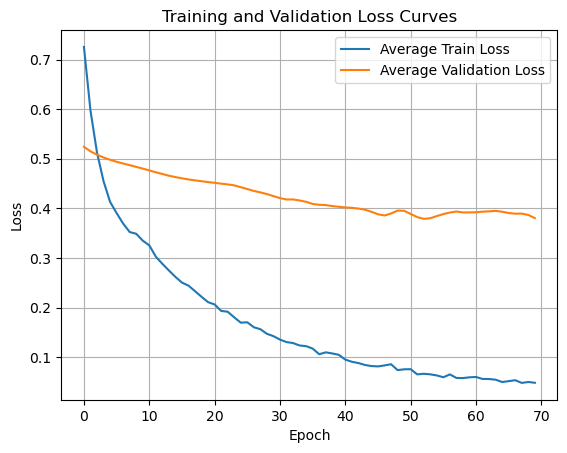

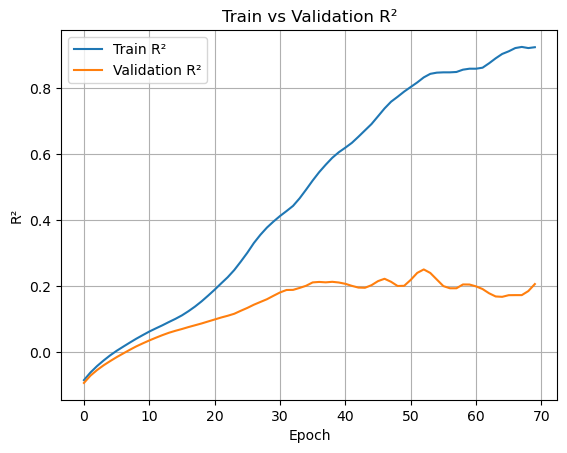


Final results:
Train loss: 0.0698 ± 0.0180
Val loss: 0.3714 ± 0.0720
Train R²: 0.8220 ± 0.0883
Val R²: 0.2527 ± 0.0437


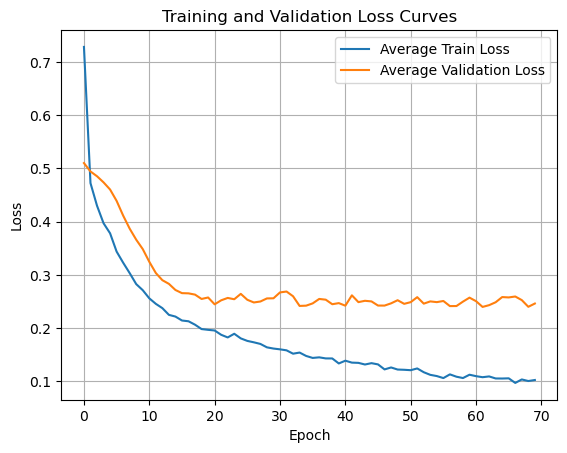

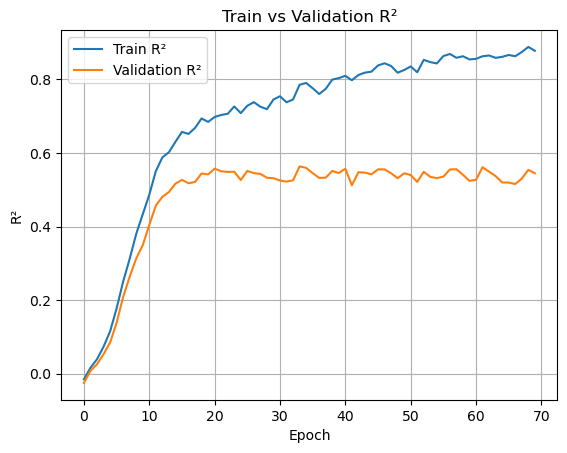


Final results:
Train loss: 0.1352 ± 0.0360
Val loss: 0.2339 ± 0.0041
Train R²: 0.8108 ± 0.0608
Val R²: 0.5745 ± 0.0153


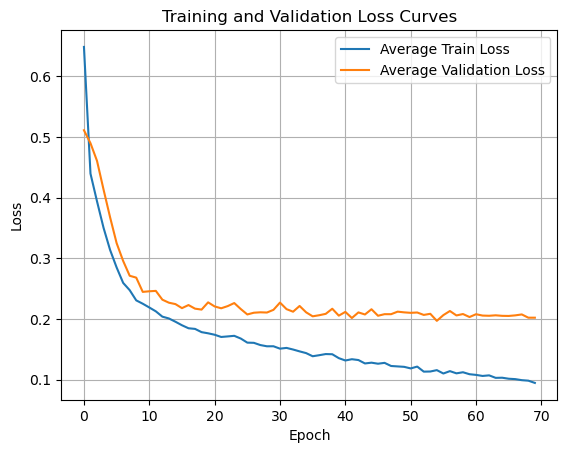

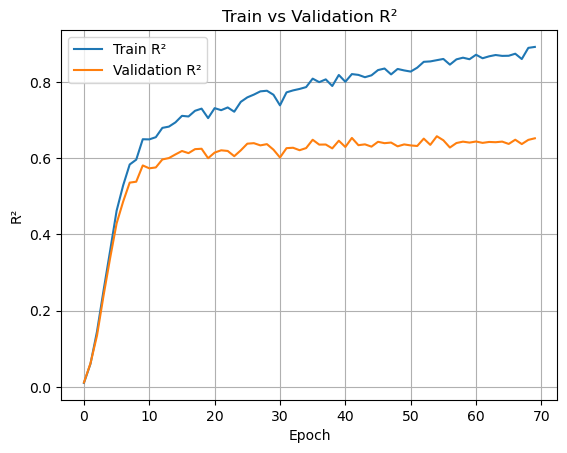


Final results:
Train loss: 0.1133 ± 0.0152
Val loss: 0.1928 ± 0.0142
Train R²: 0.8624 ± 0.0256
Val R²: 0.6642 ± 0.0216


In [36]:
# check if R^2 validation scales with number of examples as my model learns more
# if it does scale, I can continue and make my final @test_and_train function
for sample in [100, 500, 1000]: 
    # small subset
    subset = graph_dataset[:sample]  

    results = KFoldCrossValidation(
        model_class=GNN,
        graph_dataset=subset,
        k=3,
        batch_size=100,
        epochs=70,
        hidden_dim=104,
        dropout=0.18,
        lr=7e-4,
        loss_type="smoothl1",
        beta=0.76,
        device=device,
        make_plots=True,
        verbose=False # do not turn True your eyes will bleed
        # YOU HAVE BEEN WARNED
    ) # R^2 val does scale with number of samples

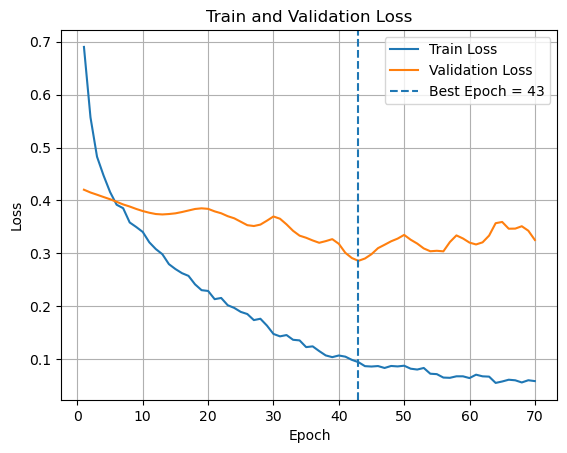

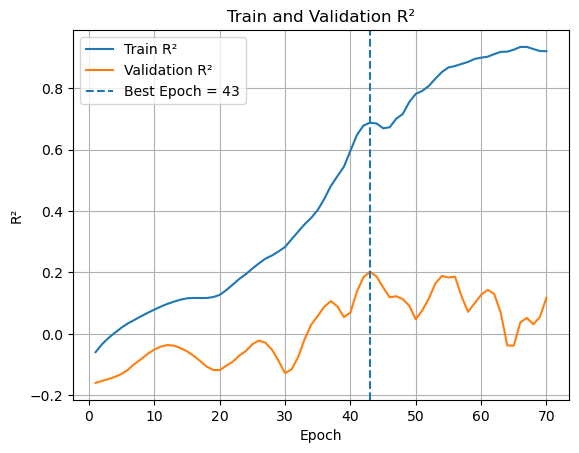

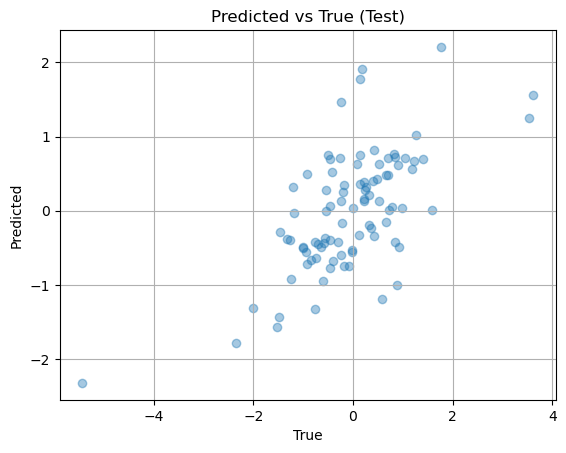

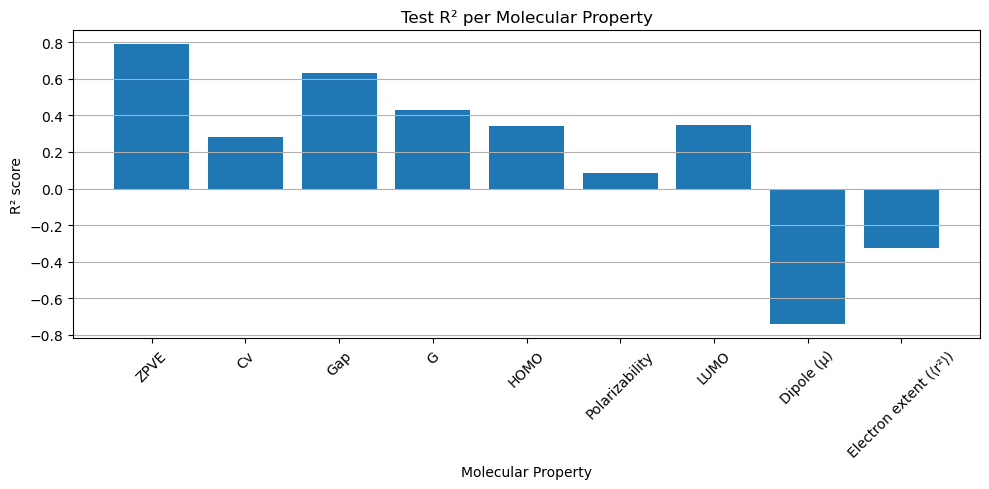

Best Epoch (by val R²): 43
Final Train R²: 0.6882
Final Train Loss: 0.1968
Final Val R²: 0.2026
Final Val Loss: 0.2859
Final Test R²: 0.2045
Final Test Loss: 0.3605


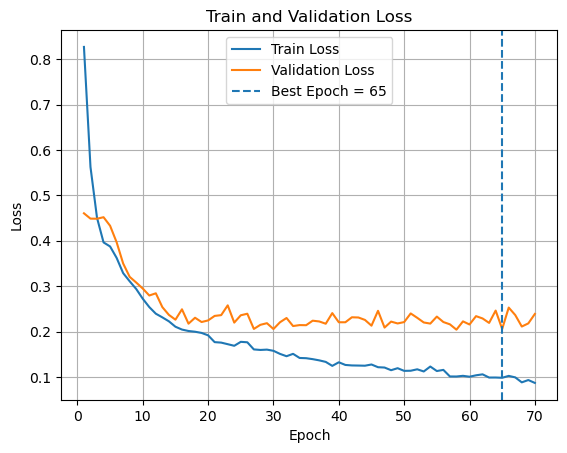

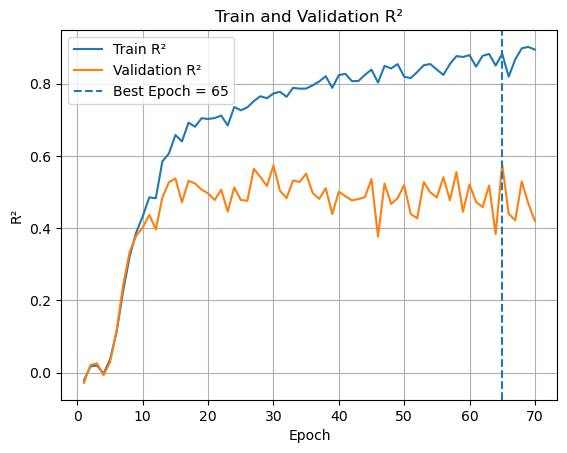

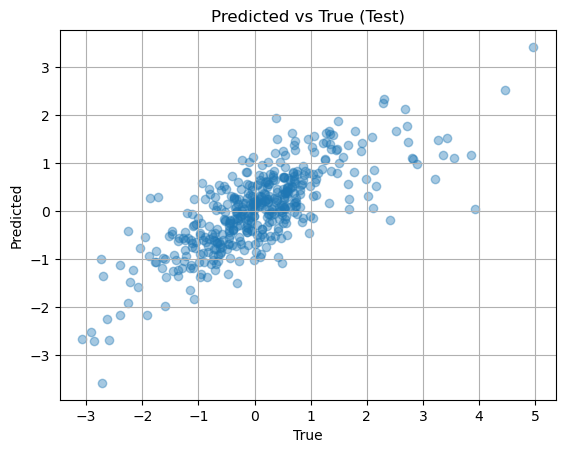

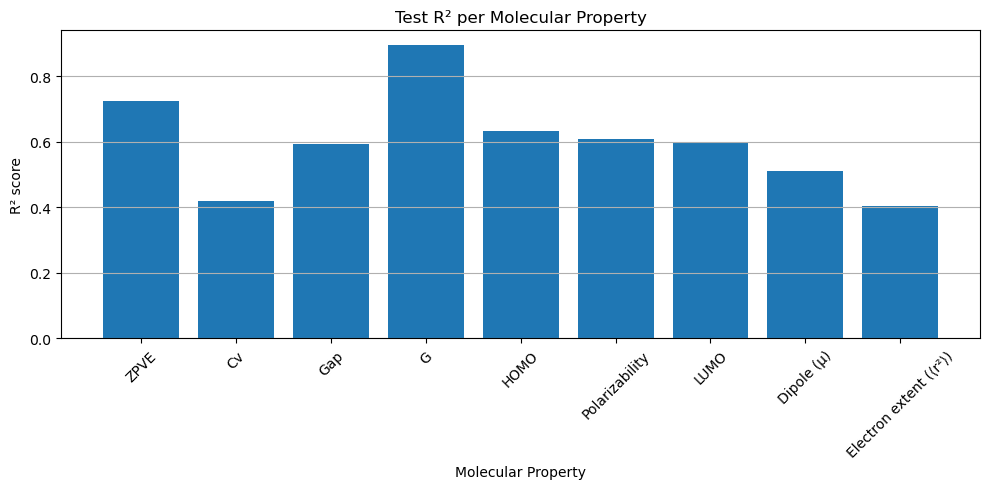

Best Epoch (by val R²): 65
Final Train R²: 0.8829
Final Train Loss: 0.0764
Final Val R²: 0.5765
Final Val Loss: 0.2058
Final Test R²: 0.5986
Final Test Loss: 0.2674


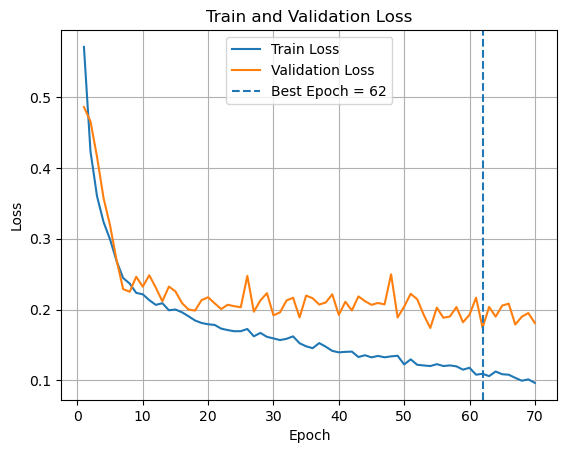

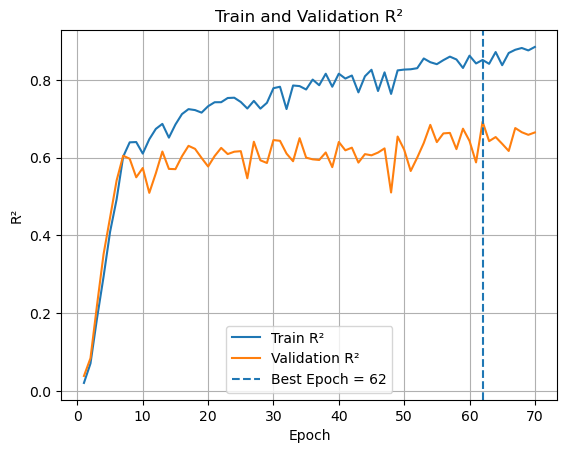

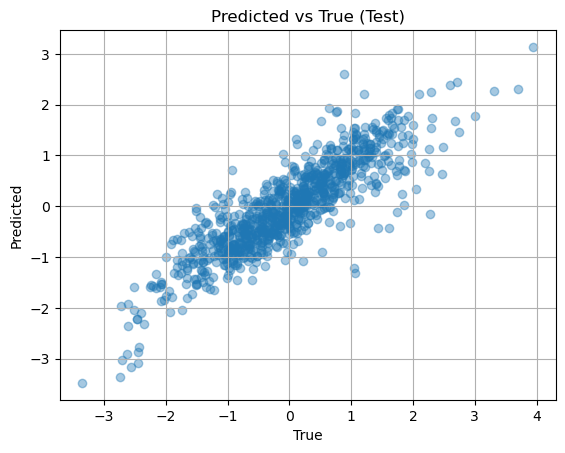

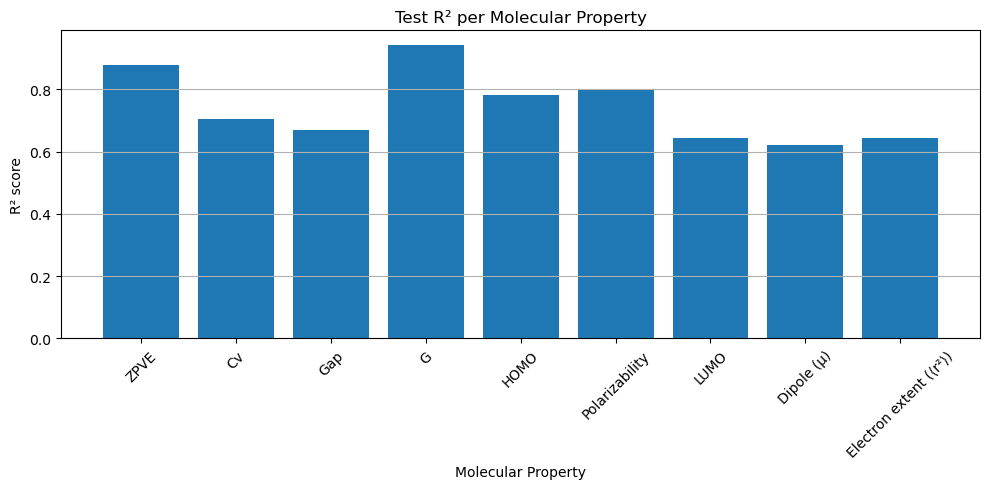

Best Epoch (by val R²): 62
Final Train R²: 0.8510
Final Train Loss: 0.0981
Final Val R²: 0.6922
Final Val Loss: 0.1744
Final Test R²: 0.7432
Final Test Loss: 0.1613


In [ ]:
# testing if my final @train_and_test function works well
# using hyperparameters approximated above

for sample in [100, 500, 1000]: 
    subset = graph_dataset[:sample]

    results = train_and_test(
        model_class=GNN,
        graph_dataset=subset,
        test_size=0.1,
        val_size=0.1, 
        batch_size=100,
        epochs=70,
        hidden_dim=104,
        dropout=0.18,
        lr=7e-4,
        loss_type="smoothl1",
        beta=0.75,
        device=device,
        random_state=67,
        show_progress=False,
        verbose=True,
        make_plots=True
    )

### (3) Create the smiles transformer that will predict the chemical reaction type. One transformer will use GNN derived information while the other will not and then compare. 

Once we run the GNN model, we will need to then run the model to get the parameters from molecules we encounter in the USPTO dataset. The predictions will be then used as features to help the transformer perform the prediction for the reaction type being performed. Make these predictions with the GNN model and append them to the reaction_types_df as a list of the list of 9 properties. For example say 2 reactants and 1 product will add onto reaction_type_df two columns: reactant_preds and product_preds. The first will have two lists for the two molecules in the reactants, each list having the 9 features. The second will just have one list/molecule again with the 9 properties. 

In [ ]:
# This is used to get the graph structure to the model to get the 9 features
# Refer to @smiles_to_graph_alchemy
def smiles_to_graph_uspto(smiles, max_angles = 6): 
    """
    NOTE: This is a new smiles to graph function 
    meant to be used for smiles in the USPTO dataset to obtain their features. 
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None

    # NOTE: Original data for GNN does not have H's
    # This is just to get rough angles and length of bonds as features
    # To use the GNN, then we will remove the H's and proceed
    mol = Chem.AddHs(mol) 
    params = AllChem.ETKDGv3()
    params.randomSeed = 67

    # attempt no.1 of getting coords (least accurate, always will return something)
    if AllChem.EmbedMolecule(mol, params) != 0: return None 
    if AllChem.MMFFHasAllMoleculeParams(mol):
        try: AllChem.MMFFOptimizeMolecule(mol)
        except: pass # attempt no. 2 (most accurate for small organic molecules)
    elif AllChem.UFFHasAllMoleculeParams(mol):
        try: AllChem.UFFOptimizeMolecule(mol)
        except: pass # attempt no. 3 (less accurate than MMFF but more accurate them ETKDGv3)

    conf = mol.GetConformer()
    coords = [
        [conf.GetAtomPosition(i).x,
         conf.GetAtomPosition(i).y,
         conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())]
    
    # get heavy atom indices BEFORE removing H's (important for correct indexing)
    # did not use Chem.RemoveAllHs(mol) else alignment with variable coords
    heavy_idx = [i for i, atom in enumerate(mol.GetAtoms()) if atom.GetAtomicNum() != 1]
    coords = [coords[i] for i in heavy_idx]

    y_dummy = [0.0] * 9 # not needed, shove in dummy

    return smiles_to_graph_alchemy(
        smiles, # the original smiles string that had all the chiral hydrogens 
        coords,
        y_dummy,
        max_angles=max_angles
    )


@torch.no_grad()
def predict_smiles(model, smiles, device):
    model.eval()

    data = smiles_to_graph_uspto(smiles)
    if data is None: return None
    data = data.to(device)

    pred = model(data.x, data.edge_index, data.edge_attr, data.batch)
    return pred.reshape(1, -1).cpu().numpy().flatten().tolist()


def get_structure_preds(model, smiles_string, device): 
    """
    Input
    =====
        smiles_string : string like "A.B.C" or "A" 
    Output
    ======
        list of predictions (one per molecule)
        where each prediction is a list of 9 values or None
    """

    if pd.isna(smiles_string): return []
    smiles_list = [s.strip() for s in smiles_string.split(".") if s.strip()]
    
    return [predict_smiles(model, smi, device) for smi in smiles_list]

In [ ]:
# For now, convert a subset of the reaction data just to work on the next step of the pipeline
# which is the transformer

N = 1000

subset = reaction_types_df.iloc[:N].copy()

subset["reactant_preds"] = [
    get_structure_preds(results["model"], x, device)
    for x in tqdm(subset["reactant"])
]

subset["product_preds"] = [
    get_structure_preds(results["model"], x, device)
    for x in tqdm(subset["product"])
]

display(subset)

100%|██████████| 1000/1000 [02:10<00:00,  7.64it/s]


,reactant,product,category,reactant_preds,product_preds
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1,"[[4.6021599769592285, 12.43106746673584, -2.37...","[[6.876236915588379, 17.548200607299805, -2.11..."
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4,"[[5.967043876647949, 16.05327606201172, -2.720...","[[8.160659790039062, 19.879602432250977, -2.98..."
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2,"[[6.25845193862915, 16.265722274780273, -0.939...","[[6.183290481567383, 16.133686065673828, -1.06..."
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1,"[[6.434945583343506, 15.344219207763672, -2.76...","[[6.996882915496826, 18.29009437561035, -2.815..."
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9,"[[6.609534740447998, 19.167266845703125, -3.64...","[[7.680324554443359, 20.15738296508789, -2.698..."
...,...,...,...,...,...
995,CC(C)(C)OC(=O)N1CCC(c2ccccc2Sc2c[nH]c3ccccc23)CC1,c1ccc(C2CCNCC2)c(Sc2c[nH]c3ccccc23)c1,6,"[[8.580629348754883, 20.56952667236328, -2.104...","[[9.334712982177734, 21.694543838500977, -2.57..."
996,CCCN(CCO)C(=O)OC(C)(C)C.Cc1nc(Cl)ccc1[N+](=O)[O-],CCCN(CCOc1ccc([N+](=O)[O-])c(C)n1)C(=O)OC(C)(C)C,1,"[[5.270142555236816, 13.314183235168457, -0.63...","[[5.982029914855957, 15.710203170776367, -1.81..."
997,CN(C(=O)OC(C)(C)C)[C@H](Cc1ccc(O)cc1)C(=O)O.Nc...,CN(C(=O)OC(C)(C)C)[C@H](Cc1ccc(O)cc1)C(=O)Nc1c...,2,"[[6.486540794372559, 16.330358505249023, -1.49...","[[8.19213581085205, 20.585939407348633, -2.512..."
998,CC1CCCNC1.O=C(c1ccc(Cl)cc1)c1cc([N+](=O)[O-])c...,CC1CCCN(c2ccc([N+](=O)[O-])cc2C(=O)c2ccc(Cl)cc...,1,"[[6.149969100952148, 13.228254318237305, -1.06...","[[7.817277431488037, 19.527793884277344, -2.66..."


We can now get started with making the transformer herself. We will only have one transfomer model code with some boolean include_gnn that will include our curated GNN data.

In [ ]:
# special tokens that will be used in transformer
pad_token = "[PAD]" # pad things out
unk_token = "[UNK]" # unknown

react_mol_token = "[RMOL]" # beginning of reactant molecule block
prod_mol_token = "[PMOL]"  # beginning of product molecule block
react_gnn_token = "[RGNN]" # token to be replaced by the reactant gnn vector
prod_gnn_token = "[PGNN]"  # token to be replaced by the product gnn vector 
sep_token = "[SEP]"        # seperator between the reactant side and the product side

# token functions and smiles 
def tokenize_smiles(smi): 
    """
    Tokenizes SMILES while preserving: 
        1. Braketed groups like [NH4+], [O-]
        2. Multicharacter atoms (namely in our study, just Cl) (refer to @alchemy_elements)
        3. Reaction Arrow (>>)
        4. Ring closures (%10)
        5. Everything else is single-character (C, H, O, F, ...)
    """
    tokens = []
    i = 0
    n = len(smi) 

    while i < n: # have not used a while loop in years omg
        # this block preserves groups like [NH4+] 
        if smi[i] == "[":
            j = i + 1
            while j < n and smi[j] != "]": 
                j += 1
            if j < n:
                tokens.append(smi[i:j+1])
                i = j + 1
            else:
                tokens.append(smi[i])
                i += 1
        # whenever you see a reaction arrow
        elif i + 1 < n and smi[i:i+2] == ">>":
            tokens.append(">>")
            i += 2
        # whenever you close a ring (10%)
        elif i + 2 < n and smi[i] == "%" and smi[i+1:i+3].isdigit():
            tokens.append(smi[i:i+3])
            i += 3
        # whenever you see chlorine
        elif i + 1 < n and smi[i:i+2] in ["Cl"]:
            tokens.append(smi[i:i+2])
            i += 2
        # everything else just single char
        else:
            tokens.append(smi[i])
            i += 1
    return tokens


# helper functions to clean the gnn prediction vectors just in case
# make sure the gnn vec always is always length 9
def clean_pred_vec(pred, dim = 9): 
    if pred is None: return [0.0] * dim
    if isinstance(pred, list) and len(pred) == dim: return [float(x) for x in pred]
    return [0.0] * dim # if all goes bad at least

# make sure the list of gnn vecs is always a list and not None
def ensure_prediction_list(preds):
    if preds is None: return []
    if isinstance(preds, list): return preds
    return []

# build a mixed token sequence for one reaction
def build_reaction_tokens(
        reactant_smiles, 
        product_smiles, 
        reactant_preds = None, 
        product_preds = None, 
        include_gnn_vec = False,
): 
    """
    Output
    ======
    include_gnn_vec = False 
        uses the smiles strings only
    include_gnn_vec = True
        uses the smiles strings and gnn vec

    Examples
    ========
    SMILES-only:
        [RMOL] A [RMOL] B [SEP] [PMOL] C
    GNN mode:
        [RMOL] [RGNN] A [RMOL] [RGNN] B [SEP] [PMOL] [PGNN] C
    """

    reactant_parts = [s.strip() for s in reactant_smiles.split(".") if s.strip()]
    product_parts = [s.strip() for s in product_smiles.split(".") if s.strip()]

    if include_gnn_vec:
        reactant_preds = ensure_prediction_list(reactant_preds)
        product_preds = ensure_prediction_list(product_preds)

    tokens = []
    gnn_mask = []
    gnn_values = []

    # reactants
    for i, smi in enumerate(reactant_parts):

        tokens.append(react_mol_token)
        gnn_mask.append(0)
        gnn_values.append([0.0] * 9)

        if include_gnn_vec:
            mol_pred = clean_pred_vec(
                reactant_preds[i] if i < len(reactant_preds) else None
            )
            tokens.append(react_mol_token)
            gnn_mask.append(1) # is a gnn vec
            gnn_values.append(mol_pred)

        for tok in tokenize_smiles(smi):
            tokens.append(tok)
            gnn_mask.append(0) # is not a gnn vec
            gnn_values.append([0.0] * 9)

    # rxn arrow seperator
    tokens.append(sep_token)
    gnn_mask.append(0) 
    gnn_values.append([0.0] * 9)

    # products
    for i, smi in enumerate(product_parts):

        tokens.append(prod_mol_token)
        gnn_mask.append(0) # is not a gnn vec
        gnn_values.append([0.0] * 9)

        if include_gnn_vec:
            mol_pred = clean_pred_vec(
                product_preds[i] if i < len(product_preds) else None
            )

            tokens.append(prod_gnn_token)
            gnn_mask.append(1) # is a gnn vec
            gnn_values.append(mol_pred)

        for tok in tokenize_smiles(smi):
            tokens.append(tok)
            gnn_mask.append(0) # is not a gnn vec
            gnn_values.append([0.0] * 9)
    
    return tokens, gnn_mask, gnn_values

class ReactionTokenizer: 
    def __init__(self): 
        # token2index is the main vocab dict mapping token to int id
        self.token2idx = {
            pad_token: 0, 
            unk_token: 1, 
            react_mol_token: 2, 
            prod_mol_token: 3, 
            react_gnn_token: 4, 
            prod_gnn_token: 5,
            sep_token: 6, 
        }
        self.idx2token = {idx: tok for tok in self.token2index.items()}

    def add_token(self, token):
        if token not in self.token2index: 
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx] = token

    def build_vocab(self, df): 
        # add all smile tokens from react and prod 
        for _, row in df.iterrows(): 
            for tok in tokenize_smiles(row["reactant"]): self.add_token(tok)
            for tok in tokenize_smiles(row["product" ]): self.add_token(tok)

    def encode_tokens(self, tokens): 
        # return an array integers for the token
        # if not return the int for the unknown (.get(...))
        unk_idx = self.token2idx[unk_token]
        return [self.token2idx.get(tok, unk_idx) for tok in tokens]
    
    def decode_ids(self, ids):
        # return an array of the ids of from the idx
        # if not return the idx for the unknown (.get(...))
        return [self.idx2token.get(i, unk_token) for i in ids]
    
    @property # decorator for a class variable
    # example: ReactionTokenizer.vocab_size
    def vocab_size(self):
        return len(self.token2idx)

# convert df of reactions I made into something pytorch can train on 
class ReactionDataset(Dataset): 
    def __init__(self, df, tokenizer, include_gnn_vec = False): 
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.include_gnn_vec = include_gnn_vec
        self.labels = self.df["category"].tolist()

    def __len__(self): 
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        tokens, gnn_mask, gnn_values = build_reaction_tokens(
            reactant_smiles=row["reactant"],
            product_smiles=row["product"],
            reactant_preds=row.get("reactant_preds", None),
            product_preds=row.get("product_preds", None),
            include_gnn_vec=self.include_gnn_vec
        )

        input_ids = torch.tensor(
            self.tokenizer.encode_tokens(tokens),
            dtype=torch.long
        )

        # 1 means real token, 0 means padding
        attention_mask = torch.ones(len(tokens), dtype=torch.long)

        # marks which positions correspond to [RGNN] or [PGNN]
        gnn_mask = torch.tensor(gnn_mask, dtype=torch.bool)

        # per-token 9-dim GNN
        gnn_values = torch.tensor(gnn_values, dtype=torch.float)

        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "gnn_mask": gnn_mask,
            "gnn_values": gnn_values,
            "label": label,
        }
    
from torch.nn.utils.rnn import pad_sequence

def reaction_collate_fn(batch):
    """
    Pad variable-length reaction sequences into one batch.
    """
    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item["attention_mask"] for item in batch]
    gnn_mask = [item["gnn_mask"] for item in batch]
    gnn_values = [item["gnn_values"] for item in batch]
    labels = torch.stack([item["label"] for item in batch])

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    gnn_mask = pad_sequence(gnn_mask, batch_first=True, padding_value=0)
    gnn_values = pad_sequence(gnn_values, batch_first=True, padding_value=0.0)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "gnn_mask": gnn_mask,
        "gnn_values": gnn_values,
        "label": labels,
    }

 


SyntaxError: invalid syntax (4201291611.py, line 153)

## Endgame
$\bold{\text{Using the whole alchemy and uspto dataset}}$, run the transformer by itself to see if chemical reactions are well-predicted. Then, run the GNN, couple it to the transfomer, and see if reactions are even more greatly correctly predicted!

In [ ]:
# # run the final model 
# 
# results = train_and_test(
#     model_class=GNN,
#     graph_dataset=graph_dataset,
#     test_size=0.1,
#     batch_size=112,
#     epochs=70,
#     hidden_dim=124,
#     dropout=0.225,
#     lr=6e-4,
#     loss_type="smoothl1",
#     beta=0.6,
#     device=device,
#     random_state=67,
#     show_progress=False,
#     verbose=True,
#     make_plots=True
# )

In [ ]:
# # this cell will take around an hour to run on mps single core
# # run this at the end of the project to get predictions
# reaction_types_df["reactant_preds"] = [
#     get_structure_preds(results["model"], x, device)
#     for x in tqdm(reaction_types_df["reactant"])
# ]
# 
# reaction_types_df["product_preds"] = [
#     get_structure_preds(results["model"], x, device)
#     for x in tqdm(reaction_types_df["product"])
# ]
# 
# display(reaction_types_df) 